# Implementing a Simple Non-LLM Workflow to process a string at node A and reverse parallely at Node B -> Leter merge into a single output

In [29]:
from langgraph.graph import START, END, StateGraph
from typing import TypedDict, Annotated
import operator
from IPython.display import Image

In [16]:
# Defining the Graph State:
class ParallelState(TypedDict):
    input: str
    output1: Annotated[list, operator.add]
    output2: Annotated[list, operator.add]
    final: str

In [25]:
# Defining the functions:

def node_a(state: ParallelState) -> dict:
    return {"output1": [state["input"].upper()]}

def node_b(state: ParallelState) -> dict:
    return {"output2": [state["input"][::-1]]}

def merge_node(state: ParallelState) -> dict:
    return {"final": f"{state['output1']} | {state['output2']}"}

In [26]:
# Defining the Graph
graph = StateGraph(ParallelState)

# Addiong Nodes
graph.add_node("A", node_a)
graph.add_node("B", node_b)
graph.add_node("Merge", merge_node)

# Adding Edges
graph.add_edge(START, "A")
graph.add_edge(START, "B")
graph.add_edge("A", "Merge")
graph.add_edge("B", "Merge")
graph.add_edge("Merge", END)

# Compile:
workflow = graph.compile()

In [27]:
# Executiong the Graph:
output = workflow.invoke({"input":"Hello"})
print(output)


{'input': 'Hello', 'output1': ['HELLO'], 'output2': ['olleH'], 'final': "['HELLO'] | ['olleH']"}


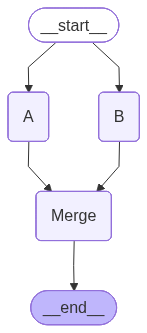

In [30]:
Image(workflow.get_graph().draw_mermaid_png())